In [1]:
from paws.io import get_spacing
import numpy as np
import os
import time
import yaml 
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
import matplotlib
from search import search_range

mplparams = {
    'text.usetex': False,  # use LaTeX for all text
    'axes.linewidth': 1,  # set axes linewidths to 1
    'axes.grid': False,  # add a grid
    'axes.labelweight': 'normal',
    'font.family': 'DejaVu Sans',
    'font.size': 20  # Reduced from 22 to prevent overlap
}

matplotlib.rcParams.update(mplparams)
plt.rcParams["mathtext.fontset"] = "cm"
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

with open('/scratch/kriles_root/kriles0/damoncht/simGlitch/config/config.yaml', 'r') as f:
    config = yaml.safe_load(f)

with open('/scratch/kriles_root/kriles0/damoncht/simGlitch/targets/casa.yaml', 'r') as f:
    target = yaml.safe_load(f)

coh_mm = config['coh_mm'] 
factor = 10

In [2]:
for tcoh in [5, 10, 20, 40]:
    
    filename = f'/scratch/kriles_root/kriles0/damoncht/simGlitch/results/{tcoh}d/ng_f0/100-100Hz/CW0.fts'
    df = get_spacing(filename, 2)

    Df = search_range(coh_mm, tcoh*86400, factor)

    print(f"Tcoh = {tcoh} days:")
    for i, key in enumerate(df.keys()):
        print(f"{key:<10} = {df[key]:>12.6e} | search range = {Df[i]:>12.6e}")
    print("")

Tcoh = 5 days:
df         = 8.040201e-07 | search range = 8.071551e-06
df1dot     = 0.000000e+00 | search range = 1.447268e-10
df2dot     = 0.000000e+00 | search range = 6.606598e-16

Tcoh = 10 days:
df         = 4.030227e-07 | search range = 4.035776e-06
df1dot     = 0.000000e+00 | search range = 3.618169e-11
df2dot     = 0.000000e+00 | search range = 8.258248e-17

Tcoh = 20 days:
df         = 2.015113e-07 | search range = 2.017888e-06
df1dot     = 0.000000e+00 | search range = 9.045423e-12
df2dot     = 0.000000e+00 | search range = 1.032281e-17

Tcoh = 40 days:
df         = 1.008192e-07 | search range = 1.008944e-06
df1dot     = 0.000000e+00 | search range = 2.261356e-12
df2dot     = 0.000000e+00 | search range = 1.290351e-18



In [3]:
def load_result(data_label, labels, durations, n_signal, homedir='.', single_ng=True):
    """
    Loads FITS and CSV data into a dictionary structured by duration.
    """
    # Load the ground truth parameters
    csv_path = os.path.join(homedir, 'data', data_label, '100-100Hz', 'signal_glitch_params.csv')
    sp = pd.read_csv(csv_path)
    
    results = {'truth': sp, 'data': {}}

    for dur in durations:
        ng_vals, wg_vals = np.zeros(n_signal), np.zeros(n_signal)
        freq_params = np.zeros((n_signal, 2, 3)) 

        for i in range(n_signal):
            for l_idx, label in enumerate(labels):
                if l_idx == 0 and single_ng:
                    path = os.path.join(homedir, 'results', dur, label, '100-100Hz', f'CW0.fts')
                else:
                    path = os.path.join(homedir, 'results', dur, label, '100-100Hz', f'CW{i}.fts')
                with fits.open(path) as hdul:
                    data = hdul[1].data
                    freq_params[i, l_idx, 0] = data['freq'][0]
                    freq_params[i, l_idx, 1] = data['f1dot'][0]
                    freq_params[i, l_idx, 2] = data['f2dot'][0]
                    
                    if l_idx == 0: 
                        ng_vals[i] = data['mean2F'][0]
                    else: 
                        wg_vals[i] = data['mean2F'][0]
        
        results['data'][dur] = {
            'ng': ng_vals, 'wg': wg_vals, 'freqs': freq_params
        }
    
    return results

def plot_fstat_ratio(results, plot_labels):
    durations = list(results['data'].keys())
    n_dur = len(durations)
    t_glitch = results['truth']['tglitch_day'].values
    
    fig, ax = plt.subplots(n_dur, 4, figsize=(24, 4 * n_dur))
    if n_dur == 1: ax = np.expand_dims(ax, axis=0) 

    prev_ng, prev_wg = None, None

    for idx, dur in enumerate(durations):
        # Subtracting 4 to look at the non-centrality/excess 2F
        ng = results['data'][dur]['ng'] - 4
        wg = results['data'][dur]['wg'] - 4

        # Col 0: Raw F-stat Comparison with Arrows
        ax[idx, 0].scatter(t_glitch, ng+4, label=plot_labels[0], color='tab:blue', alpha=0.8)
        ax[idx, 0].scatter(t_glitch, wg+4, label=plot_labels[1], color='tab:orange', alpha=0.8)
        for i in range(len(t_glitch)):
            ax[idx, 0].annotate('', xy=(t_glitch[i], wg[i]+4), xytext=(t_glitch[i], ng[i]+4), 
                               arrowprops=dict(arrowstyle='->', color='k', alpha=0.5))
        ax[idx, 0].set_title(r'$2\mathcal{F}$' + f' ({dur})')
        ax[idx, 0].legend()
        
        # Col 1: Ratio with Arrows
        ax[idx, 1].scatter(t_glitch, ng/ng, label=plot_labels[0], color='tab:blue', alpha=0.8)
        ax[idx, 1].scatter(t_glitch, wg/ng, label=plot_labels[1], color='tab:red', alpha=0.8)
        for i in range(len(t_glitch)):
            ax[idx, 1].annotate('', xy=(t_glitch[i], wg[i]/ng[i]), xytext=(t_glitch[i], 1.0), 
                               arrowprops=dict(arrowstyle='->', color='k', alpha=0.5))
        ax[idx, 1].axhline(1, color='k', linestyle='--')
        ax[idx, 1].set_title(r'$2\mathcal{F} - 4$' + f' ratio ({dur})')

        # Col 2 & 3: Growth Histograms
        if prev_ng is not None:
            ax[idx, 2].hist(ng/prev_ng, bins=10, color='teal', edgecolor='black', alpha=0.7)
            ax[idx, 3].hist(wg/prev_wg, bins=10, color='purple', edgecolor='black', alpha=0.7)
            ax[idx, 2].set_title(f'{plot_labels[0]} Growth')
            ax[idx, 3].set_title(f'{plot_labels[1]} Growth')

        prev_ng, prev_wg = ng, wg

    plt.tight_layout()
    return fig, ax
    
def plot_params_bias(results, plot_labels, markers=['<', 's'], colors=['blue', 'red']):
    durations = list(results['data'].keys())
    n_dur = len(durations)
    sp = results['truth']
    t_glitch = sp['tglitch_day'].values
    
    # Ground truth values: f0, f1, f2
    truth_vals = [sp['f0'].values, sp['f1'].values, sp['f2'].values]
    
    fig, ax = plt.subplots(n_dur, 3, figsize=(22, 4 * n_dur))
    if n_dur == 1: ax = np.expand_dims(ax, axis=0)

    # Define LaTeX labels for the y-axis
    y_labels = [
        r'$f_0^s - f_0^t$',
        r'$f_1^s - f_1^t$',
        r'$f_2^s - f_2^t$'
    ]

    for idx, dur in enumerate(durations):
        freq_data = results['data'][dur]['freqs'] 
        
        for p_idx in range(3): # Frequency parameter index
            for l_idx in range(2): # Label index (0: No Glitch, 1: With Glitch)
                bias = freq_data[:, l_idx, p_idx] - truth_vals[p_idx]
                
                ax[idx, p_idx].scatter(
                    t_glitch, bias, 
                    color=colors[l_idx], 
                    label=plot_labels[l_idx], 
                    marker=markers[l_idx], 
                    facecolors='none', 
                    s=30 * 2 * (l_idx + 1),
                    alpha=0.8
                )
            
            ax[idx, p_idx].axhline(0, color='k', lw=1, alpha=0.5)
            ax[idx, p_idx].set_xlabel('t_glitch (days)')
            ax[idx, p_idx].set_ylabel(y_labels[p_idx])
            
            # Simplified title to just show duration
            if p_idx == 1:
                ax[idx, p_idx].set_title(r'$T_\mathrm{coh}$'+ f': {dur}')
            
            ax[idx, p_idx].grid(True, linestyle=':', alpha=0.6)
            if idx == 0: ax[idx, p_idx].legend()

    plt.tight_layout()
    return fig, ax

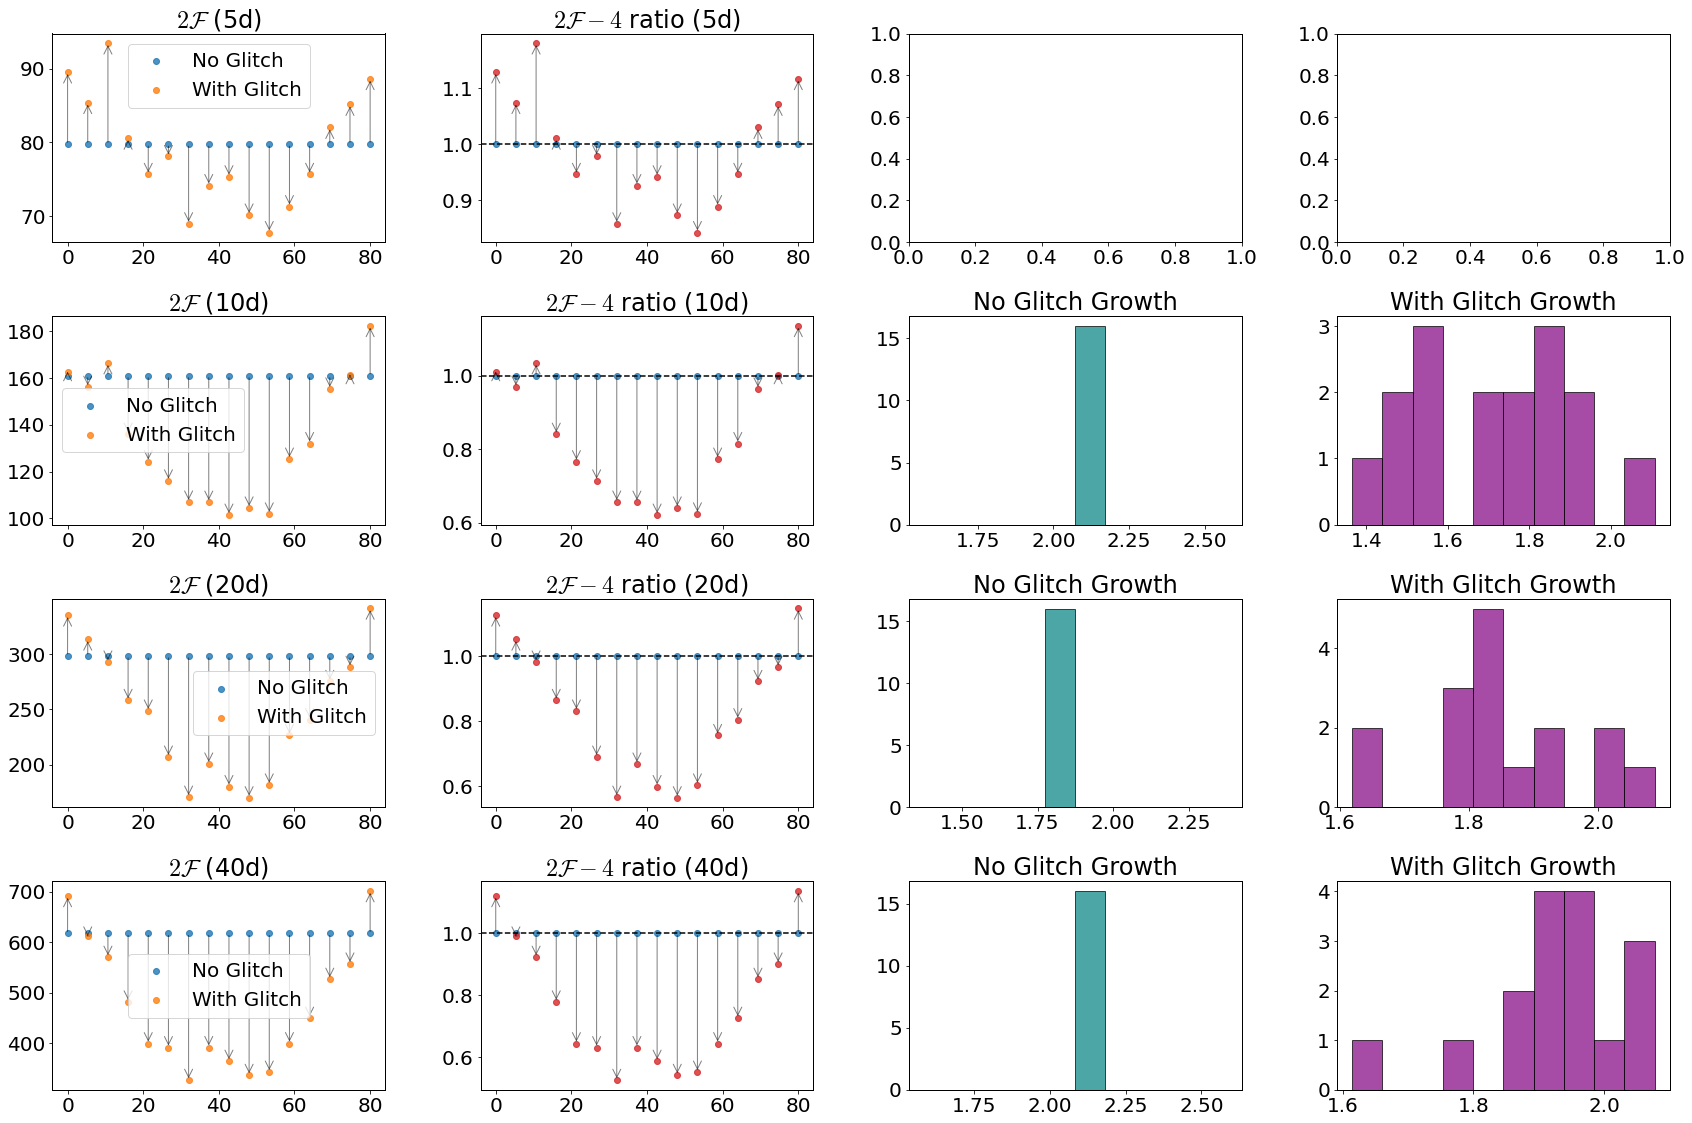

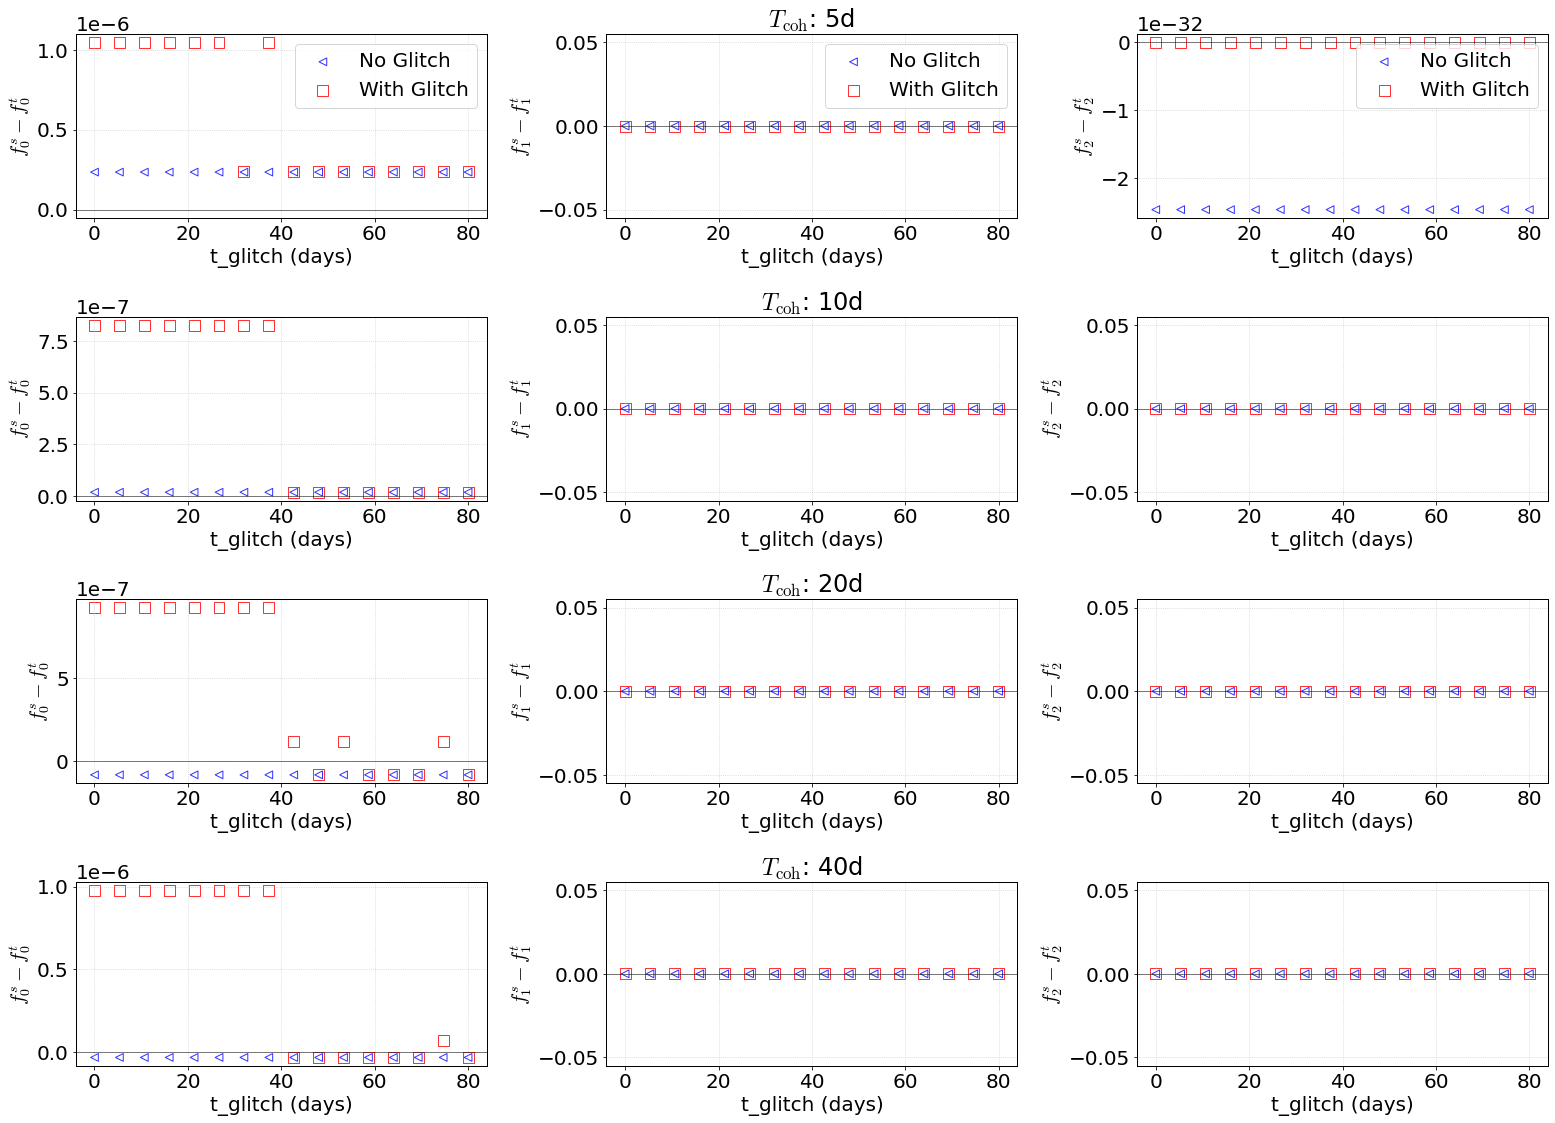

In [10]:
# 1. Define your parameters
labels = ['ng_f0', 'wg_dnu_nu_1e-8']
p_labels = ['No Glitch', 'With Glitch']
durs = ['5d', '10d', '20d', '40d']

# 2. Load the data once
results_obj = load_result(labels[1], labels, durs, n_signal=16, homedir=config['home_dir'])

# 3. Plot whenever you want
fig, ax = plot_fstat_ratio(results_obj, p_labels)

fig, ax = plot_params_bias(results_obj, p_labels)


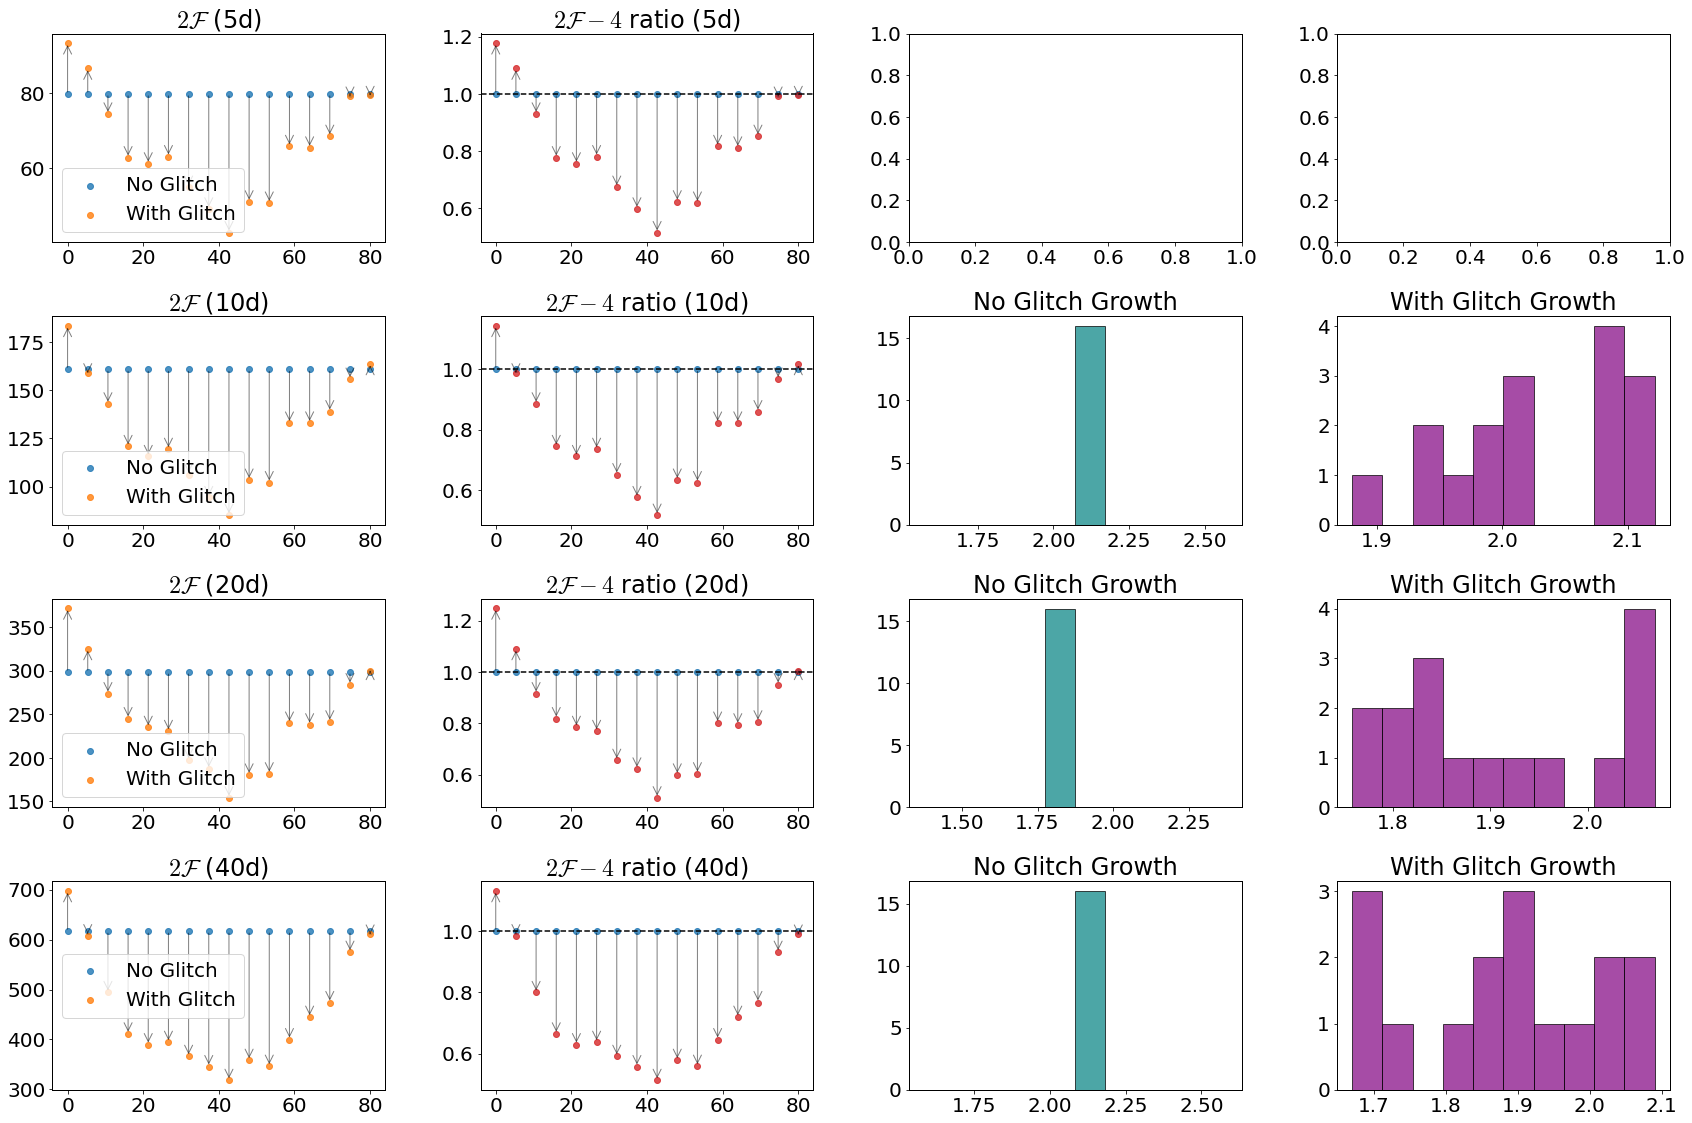

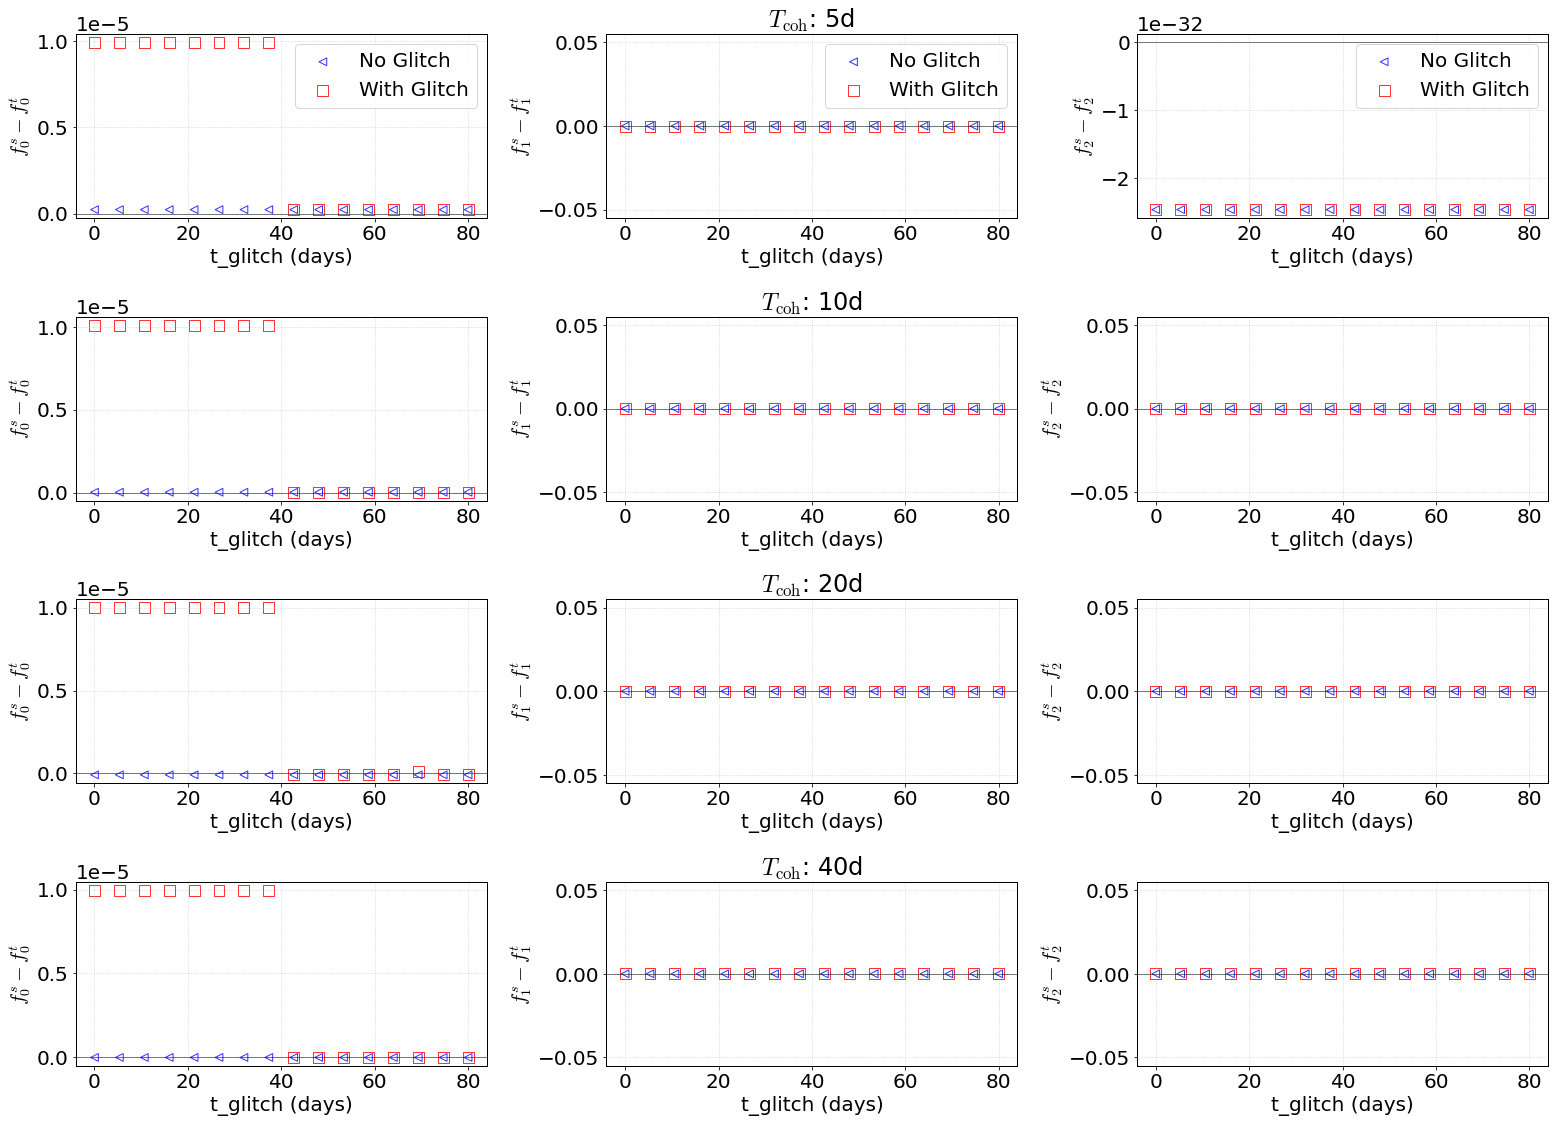

In [5]:
# 1. Define your parameters
labels = ['ng_f0', 'wg_dnu_nu_1e-7']
p_labels = ['No Glitch', 'With Glitch']
durs = ['5d', '10d', '20d', '40d']

# 2. Load the data once
results_obj = load_result(labels[1], labels, durs, n_signal=16, homedir=config['home_dir'])

# 3. Plot whenever you want
fig, ax = plot_fstat_ratio(results_obj, p_labels)

fig, ax = plot_params_bias(results_obj, p_labels)


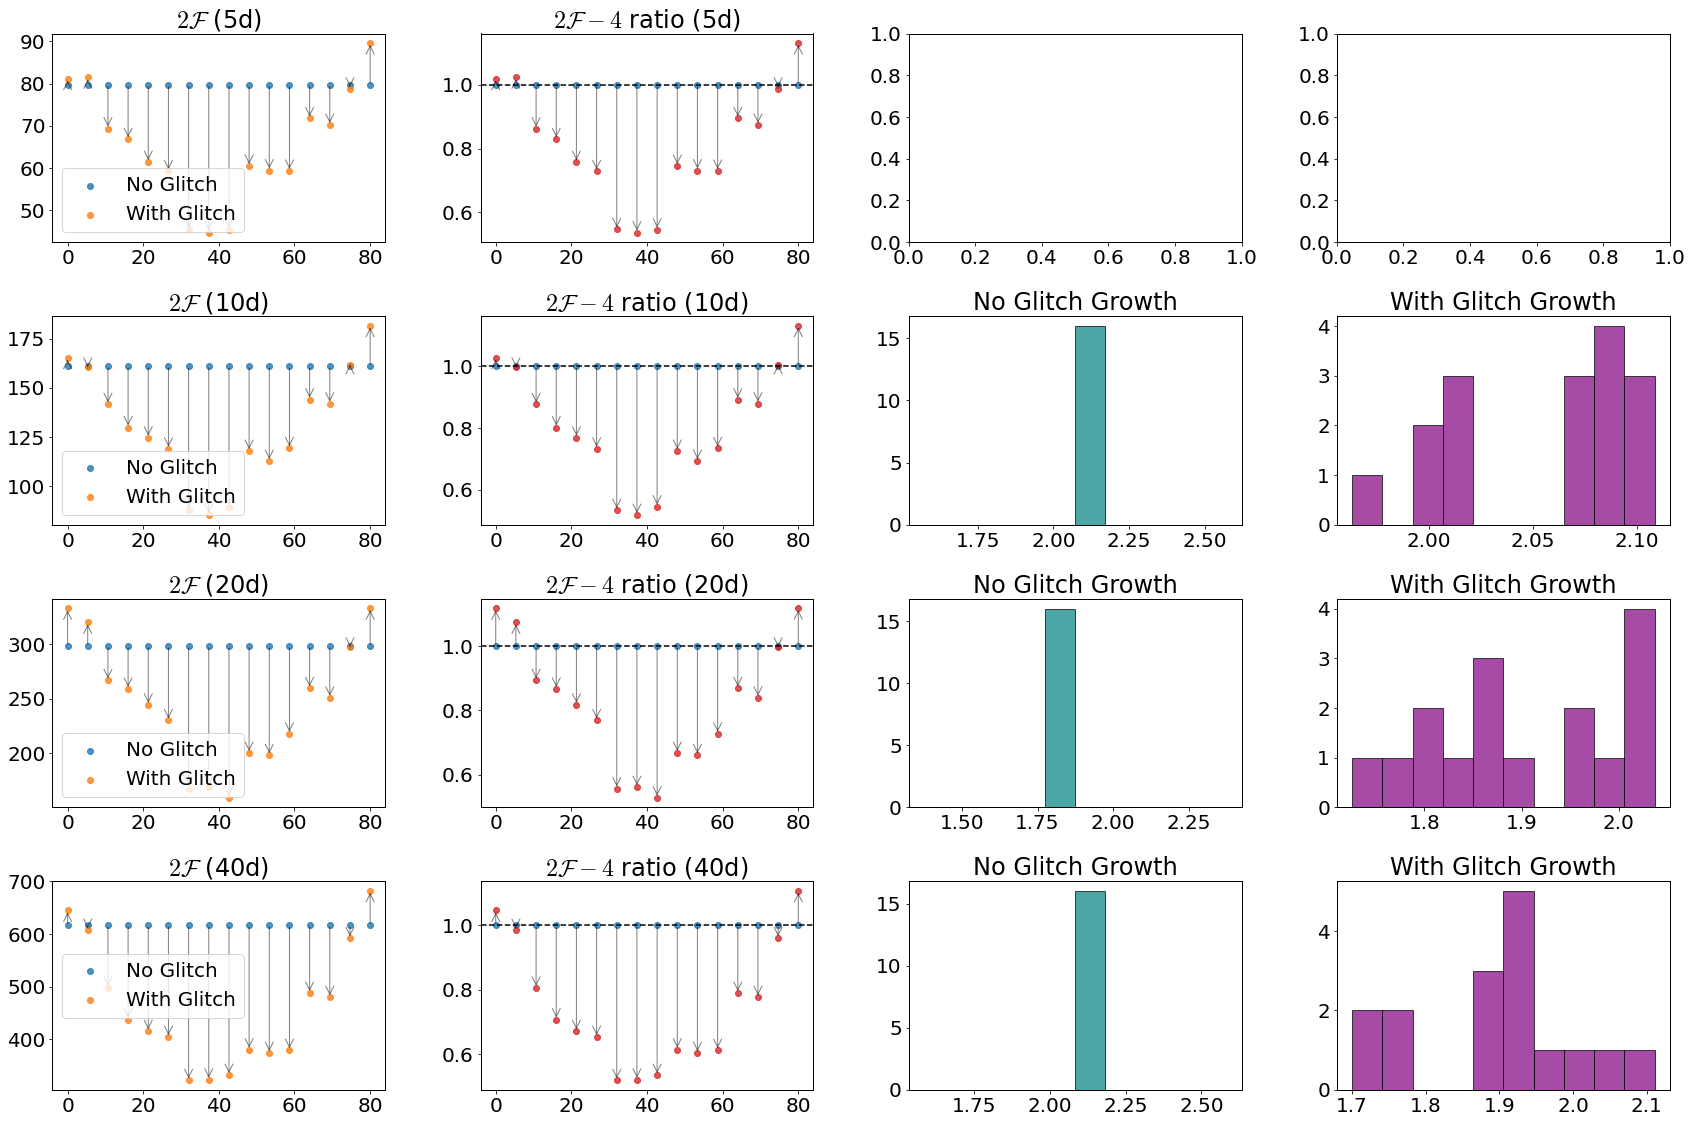

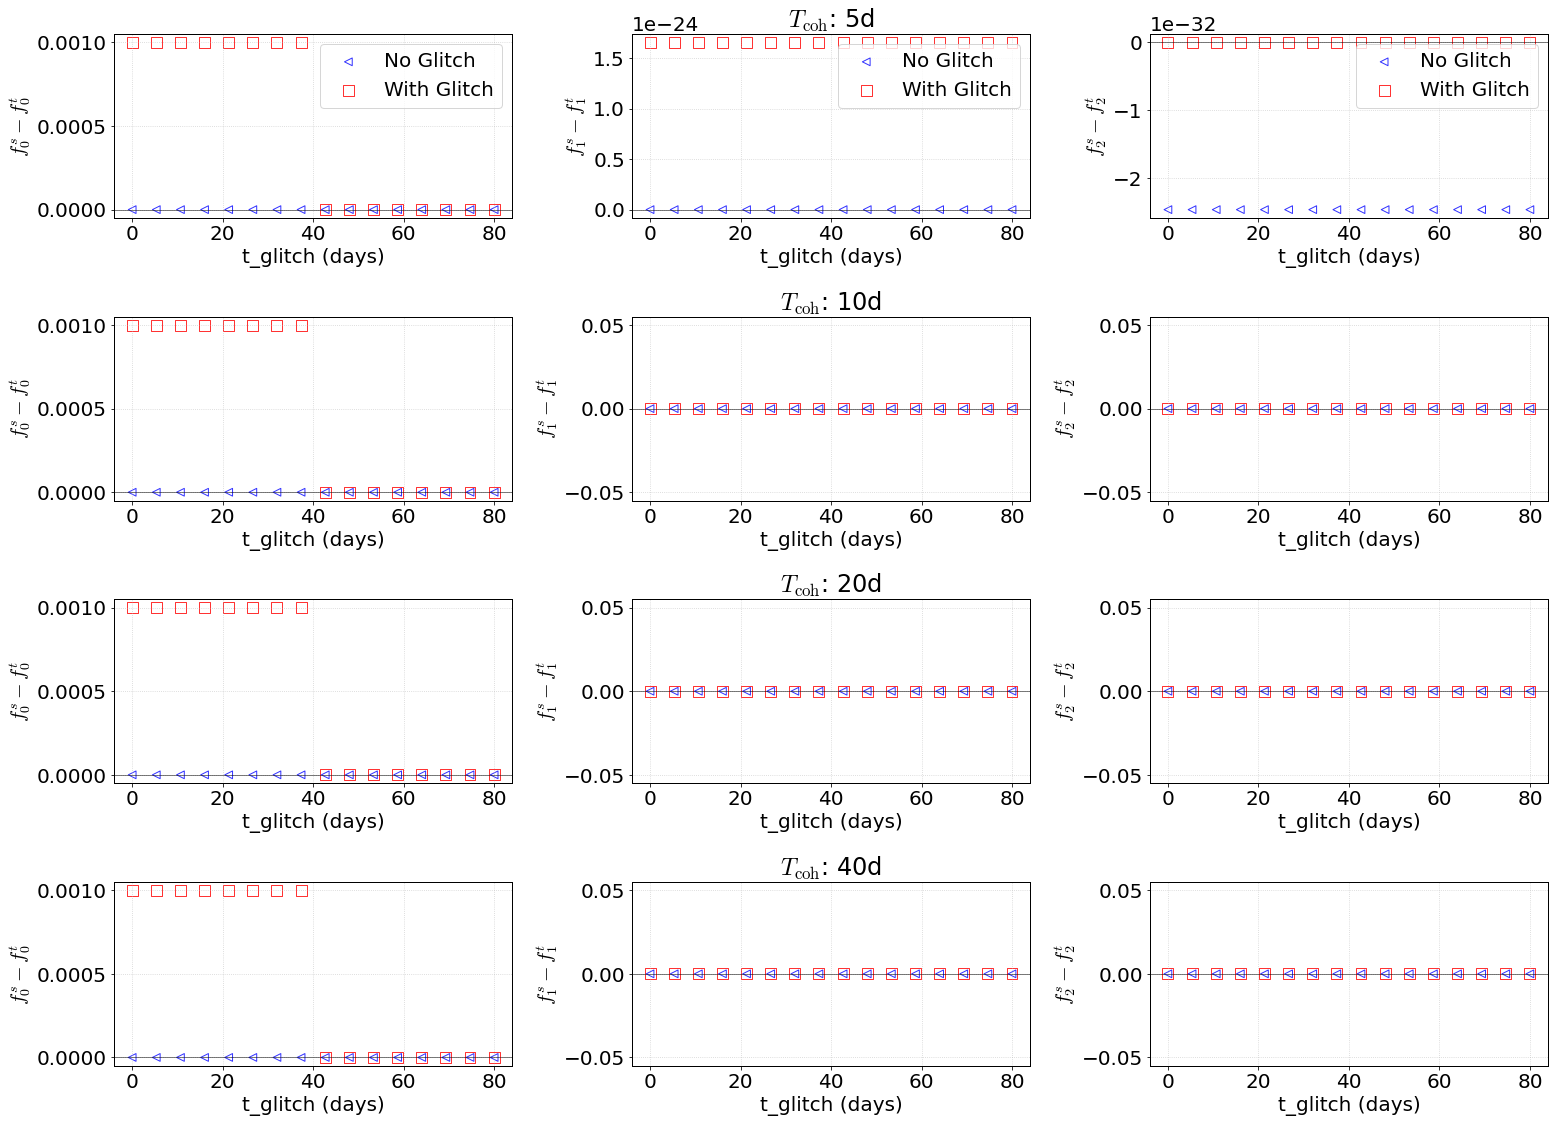

In [4]:
# 1. Define your parameters
labels = ['ng_f0', 'wg_dnu_nu_1e-5']
p_labels = ['No Glitch', 'With Glitch']
durs = ['5d', '10d', '20d', '40d']

# 2. Load the data once
results_obj = load_result(labels[1], labels, durs, n_signal=16, homedir=config['home_dir'])

# 3. Plot whenever you want
fig, ax = plot_fstat_ratio(results_obj, p_labels)

fig, ax = plot_params_bias(results_obj, p_labels)


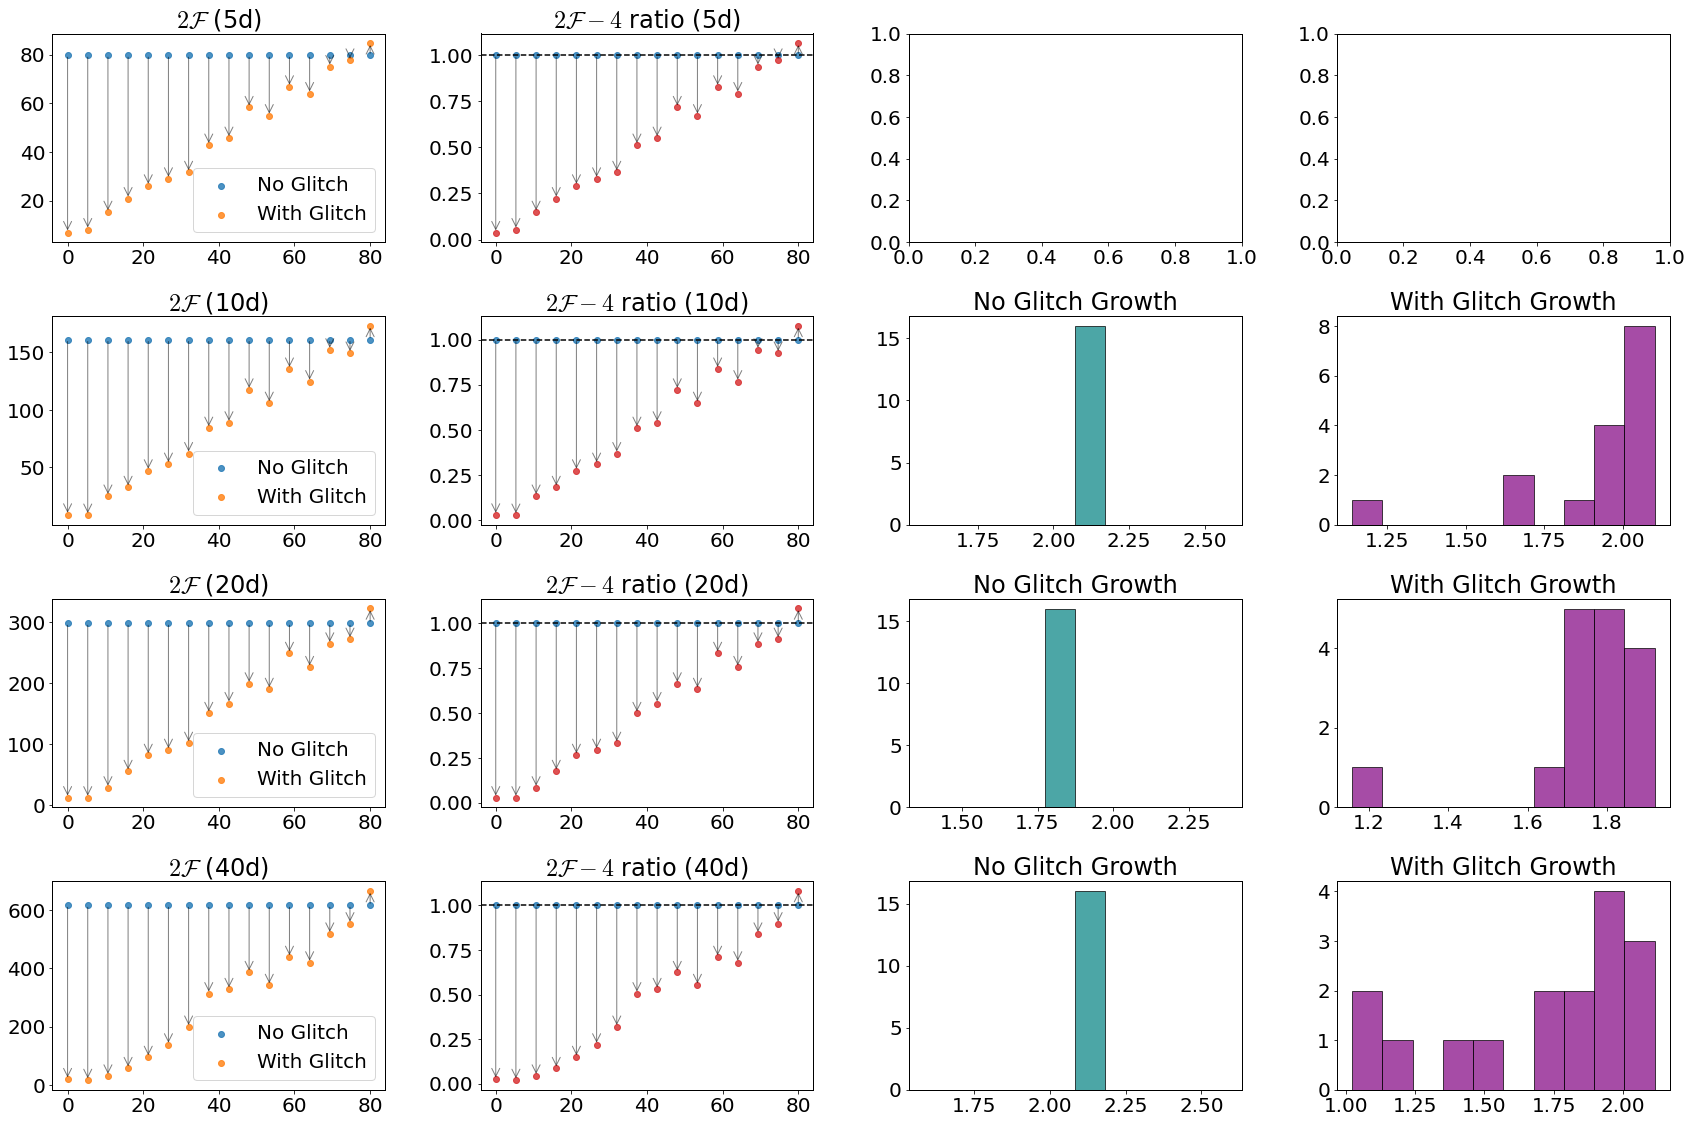

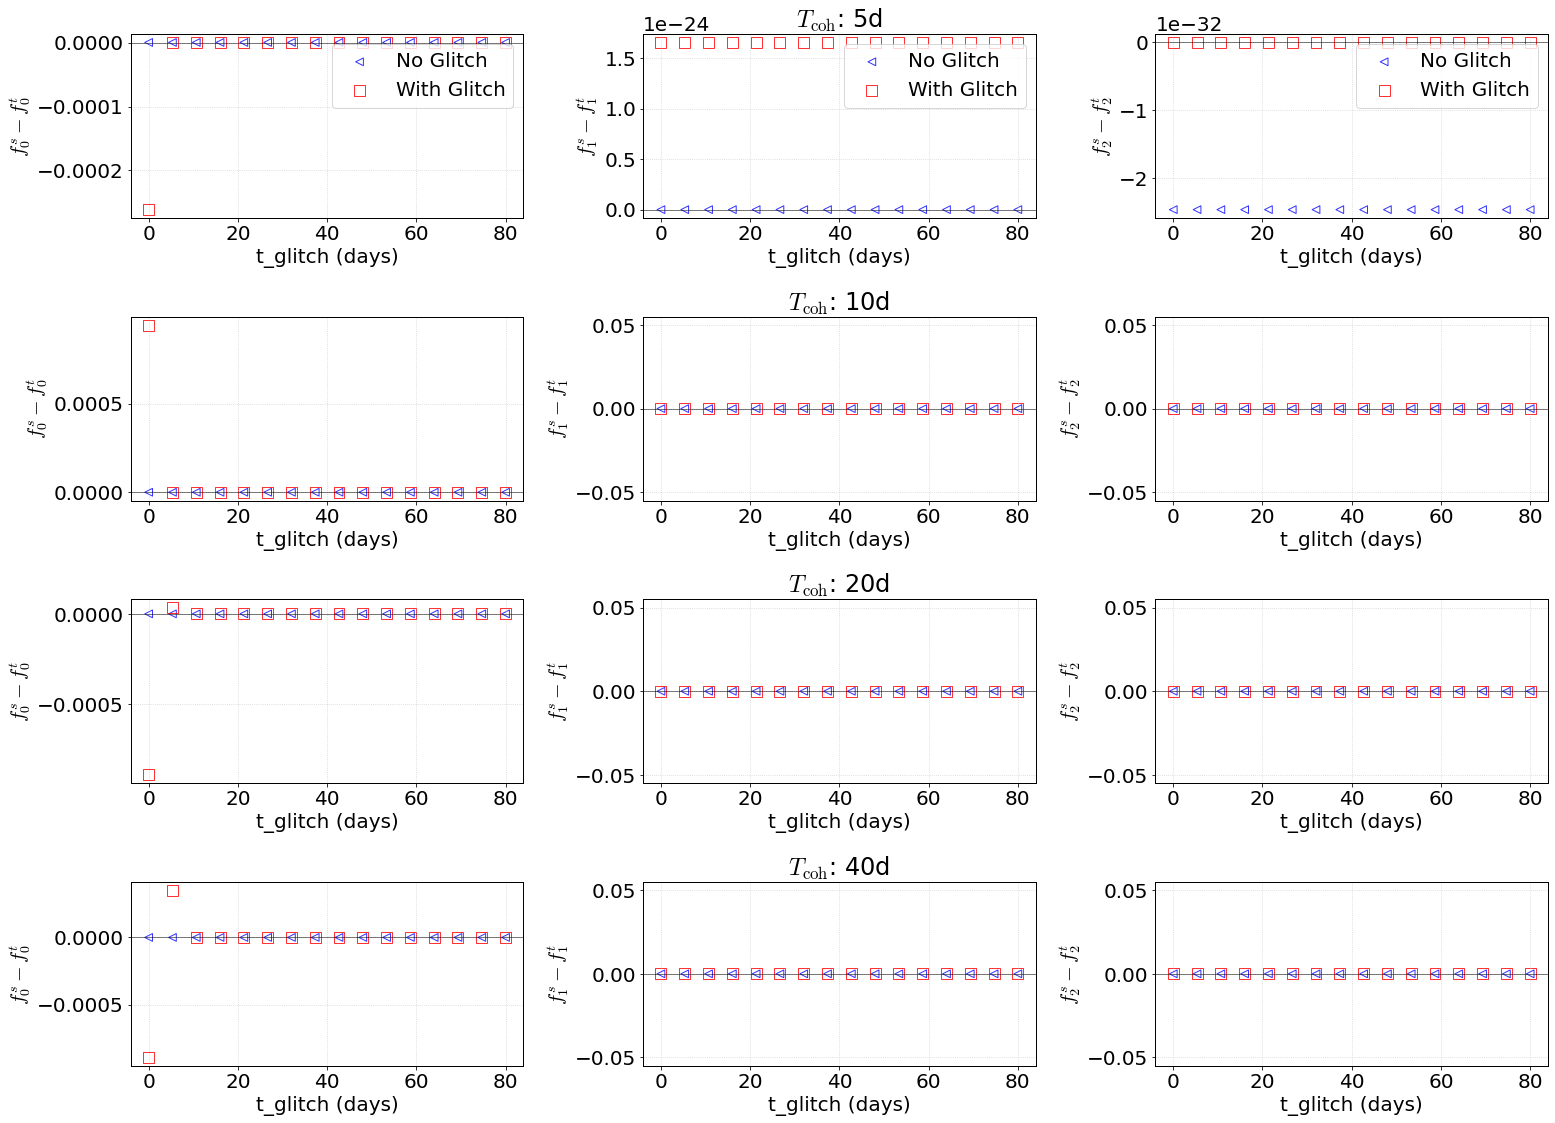

In [5]:
# 1. Define your parameters
labels = ['ng_f0', 'wg_dnu_nu_1e-4_q0.3']
p_labels = ['No Glitch', 'With Glitch']
durs = ['5d', '10d', '20d', '40d']

# 2. Load the data once
results_obj = load_result(labels[1], labels, durs, n_signal=16, homedir=config['home_dir'])

# 3. Plot whenever you want
fig, ax = plot_fstat_ratio(results_obj, p_labels)

fig, ax = plot_params_bias(results_obj, p_labels)
